# Importing the Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

# Dataset Loading

In [3]:
df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


Shape of Data

In [4]:
df.shape

(891, 15)

Info of data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [8]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Datatypes of data

In [9]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


Statistics of Data

In [10]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Finding Null values

In [11]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [12]:
df.isnull().sum() / len(df) * 100

,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,19.865320
sibsp,0.000000
parch,0.000000
fare,0.000000
embarked,0.224467
class,0.000000
who,0.000000


In [13]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)

missing_summary

,Missing_Count,Missing_Percentage
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


Handle Deck

In [14]:
df = df.drop(columns=["deck"])

In [15]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Handle Age

In [16]:
df["age"] = df["age"].fillna(df["age"].median())

In [17]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Handle Embarked

In [18]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [19]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [20]:
missing_summary_after = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary_after

,Missing_Count,Missing_Percentage
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,0,0.000000
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,0,0.000000
class,0,0.000000
who,0,0.000000


In [21]:
df.shape

(891, 14)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


In [23]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
5,0,3,male,28.0,0,0,8.4583,Q,Third,man,True,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,Cherbourg,yes,False


# Histogram

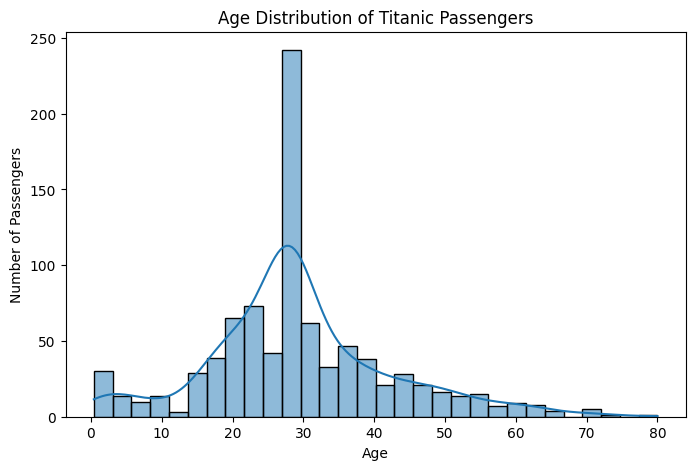

 Interpretation

The histogram shows the distribution of passenger ages in the Titanic dataset.
The distribution indicates how passengers are spread across different age groups.
Most passengers are concentrated in the younger and middle-age groups, while
fewer passengers are present at the higher age ranges.


In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

print(''' Interpretation

The histogram shows the distribution of passenger ages in the Titanic dataset.
The distribution indicates how passengers are spread across different age groups.
Most passengers are concentrated in the younger and middle-age groups, while
fewer passengers are present at the higher age ranges.''')

# Boxplot

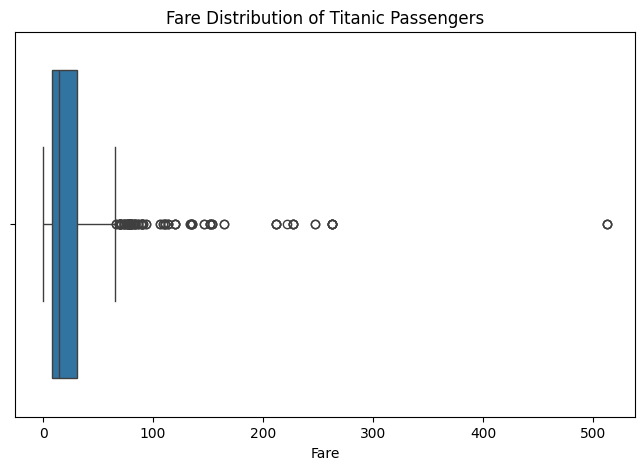

Interpretation

The box plot shows that most Titanic passenger fares are concentrated
within a relatively low range. Several observations appear beyond the
upper whisker, indicating potential high-fare outliers. There is also
an extreme fare value above 500. Overall, the fare distribution is
strongly right-skewed due to the presence of high-value fares.


In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="fare"
)

plt.title("Fare Distribution of Titanic Passengers")
plt.xlabel("Fare")

plt.show()

print('''Interpretation

The box plot shows that most Titanic passenger fares are concentrated
within a relatively low range. Several observations appear beyond the
upper whisker, indicating potential high-fare outliers. There is also
an extreme fare value above 500. Overall, the fare distribution is
strongly right-skewed due to the presence of high-value fares.''')

# Comparision Chart

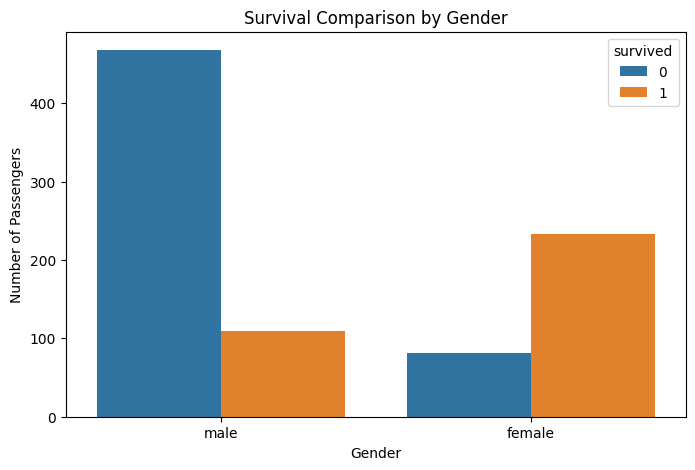

Interpretation

The survival comparison shows a clear difference between male and female
passengers. Among male passengers, the number of non-survivors is much
higher than the number of survivors. Among female passengers, the number
of survivors is higher than the number of non-survivors.

This indicates that gender is an important variable to investigate when
analyzing survival in the Titanic dataset.


In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sex",
    hue="survived"
)

plt.title("Survival Comparison by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

print('''Interpretation

The survival comparison shows a clear difference between male and female
passengers. Among male passengers, the number of non-survivors is much
higher than the number of survivors. Among female passengers, the number
of survivors is higher than the number of non-survivors.

This indicates that gender is an important variable to investigate when
analyzing survival in the Titanic dataset.''')

# Heatmap

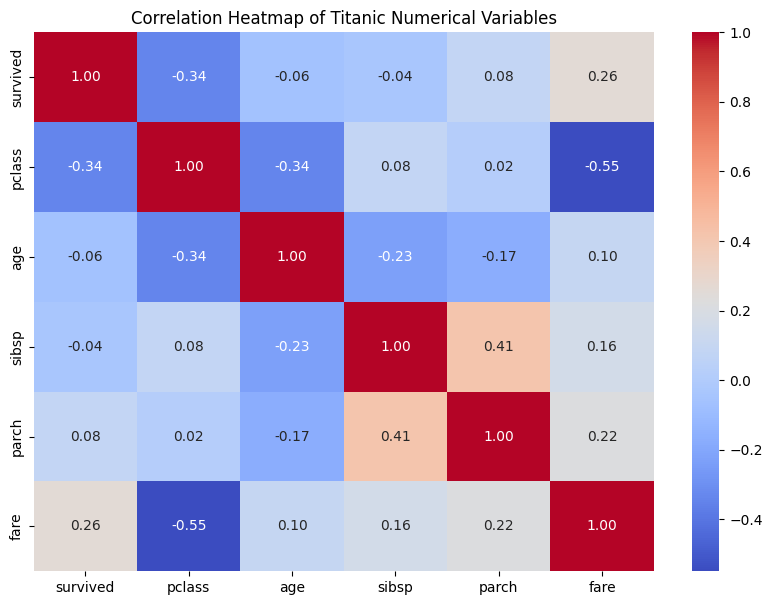

Interpretation

The correlation heatmap shows the relationships between the numerical
variables in the Titanic dataset.

The correlation between survived and pclass is -0.34, indicating a
moderate negative linear relationship. Survived and fare have a
positive correlation of 0.26.

The correlation between survived and age is -0.06, which is close to
zero and indicates a very weak linear relationship.

The strongest correlation in the heatmap is between pclass and fare,
with a correlation of -0.55. The variables sibsp and parch also show
a positive correlation of 0.41.

These correlations describe linear relationships between numerical
variables and should not be interpreted as evidence of causation.


In [27]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Titanic Numerical Variables")

plt.show()

print('''Interpretation

The correlation heatmap shows the relationships between the numerical
variables in the Titanic dataset.

The correlation between survived and pclass is -0.34, indicating a
moderate negative linear relationship. Survived and fare have a
positive correlation of 0.26.

The correlation between survived and age is -0.06, which is close to
zero and indicates a very weak linear relationship.

The strongest correlation in the heatmap is between pclass and fare,
with a correlation of -0.55. The variables sibsp and parch also show
a positive correlation of 0.41.

These correlations describe linear relationships between numerical
variables and should not be interpreted as evidence of causation.''')

# ML Pipeline

In [28]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [29]:
X = df.drop(
    columns=[
        "survived",
        "alive",
        "class",
        "embark_town",
        "who",
        "adult_male"
    ]
)

y = df["survived"]

In [30]:
X

,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,3,male,22.0,1,0,7.2500,S,False
1,1,female,38.0,1,0,71.2833,C,False
2,3,female,26.0,0,0,7.9250,S,True
3,1,female,35.0,1,0,53.1000,S,False
4,3,male,35.0,0,0,8.0500,S,True
...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,True
887,1,female,19.0,0,0,30.0000,S,True
888,3,female,28.0,1,2,23.4500,S,False
889,1,male,26.0,0,0,30.0000,C,True


In [31]:
y.value_counts(normalize=True) * 100

,proportion
survived,
0,61.616162
1,38.383838


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [33]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (712, 8)
X_test : (179, 8)
y_train: (712,)
y_test : (179,)


In [34]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

Training target distribution:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64


In [35]:
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))


Testing target distribution:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


# Numeric and Categorical Columns

In [36]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

In [37]:
categorical_features = [
    "sex",
    "embarked",
    "alone"
]

In [38]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [39]:
categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# Logistic Regression

In [41]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [42]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

In [43]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [44]:
y_pred_logistic = logistic_pipeline.predict(X_test)

In [45]:
print("Actual values:")
print(y_test.head(10).values)

print("\nPredicted values:")
print(y_pred_logistic[:10])

Actual values:
[0 0 1 0 1 1 1 0 0 0]

Predicted values:
[0 0 0 0 1 1 1 0 0 0]


# Accuracy

In [46]:
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:", accuracy_logistic)

Logistic Regression Accuracy: 0.8044692737430168


In [47]:
print(f"Accuracy: {accuracy_logistic * 100:.2f}%")

Accuracy: 80.45%


# Precision, Recall, F1

In [48]:
precision_logistic = precision_score(
    y_test,
    y_pred_logistic
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic
)

print(f"Precision: {precision_logistic:.4f}")
print(f"Recall:    {recall_logistic:.4f}")
print(f"F1 Score:  {f1_logistic:.4f}")

Precision: 0.7833
Recall:    0.6812
F1 Score:  0.7287


# Classification Report

In [49]:
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



# Confusion Matrix

In [50]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm_logistic)

[[97 13]
 [22 47]]


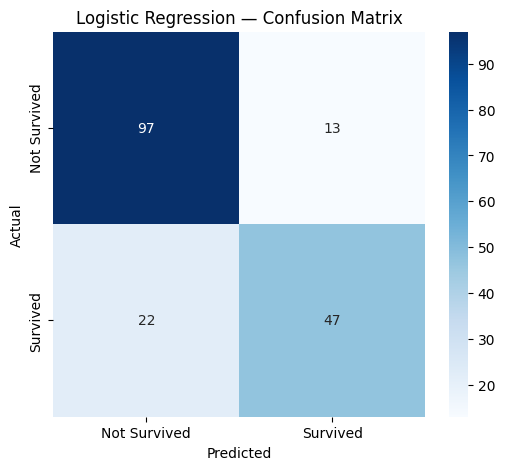

In [51]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC and AUC Curve

In [52]:
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

In [53]:
auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

print(f"Logistic Regression AUC: {auc_logistic:.4f}")

Logistic Regression AUC: 0.8510


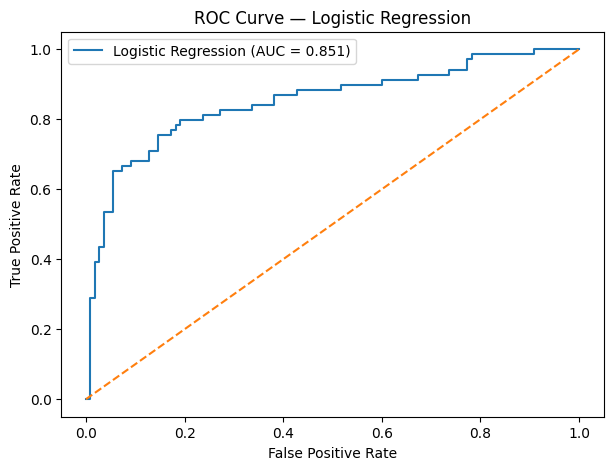

In [54]:
fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(
    y_test,
    y_prob_logistic
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()

plt.show()

In [55]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_logistic,
    "Precision": precision_logistic,
    "Recall": recall_logistic,
    "F1": f1_logistic,
    "AUC": auc_logistic
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8044692737430168,
 'Precision': 0.7833333333333333,
 'Recall': 0.6811594202898551,
 'F1': 0.7286821705426356,
 'AUC': np.float64(0.8509881422924901)}

# Decision Tree

In [56]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

In [57]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", decision_tree_model)
    ]
)

In [58]:
decision_tree_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [59]:
y_pred_tree = decision_tree_pipeline.predict(X_test)

In [60]:
print("Actual values:")
print(y_test.head(10).values)

print("\nPredicted values:")
print(y_pred_tree[:10])

Actual values:
[0 0 1 0 1 1 1 0 0 0]

Predicted values:
[0 0 0 0 1 0 1 1 0 0]


# Accuracy

In [61]:
accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)

print(f"Decision Tree Accuracy: {accuracy_tree:.4f}")
print(f"Decision Tree Accuracy: {accuracy_tree * 100:.2f}%")

Decision Tree Accuracy: 0.8212
Decision Tree Accuracy: 82.12%


# Precision, Recall, F1

In [62]:
precision_tree = precision_score(
    y_test,
    y_pred_tree
)

recall_tree = recall_score(
    y_test,
    y_pred_tree
)

f1_tree = f1_score(
    y_test,
    y_pred_tree
)

print(f"Precision: {precision_tree:.4f}")
print(f"Recall:    {recall_tree:.4f}")
print(f"F1 Score:  {f1_tree:.4f}")

Precision: 0.7937
Recall:    0.7246
F1 Score:  0.7576


In [63]:
print(
    classification_report(
        y_test,
        y_pred_tree
    )
)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



# Confusion Matrix

In [64]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

print(cm_tree)

[[97 13]
 [19 50]]


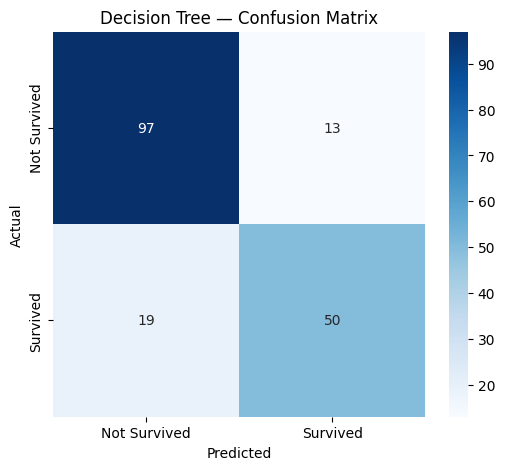

In [65]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Decision Tree — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC and AUC Curve

In [66]:
y_prob_tree = decision_tree_pipeline.predict_proba(X_test)[:, 1]

In [67]:
auc_tree = roc_auc_score(
    y_test,
    y_prob_tree
)

print(f"Decision Tree AUC: {auc_tree:.4f}")

Decision Tree AUC: 0.8018


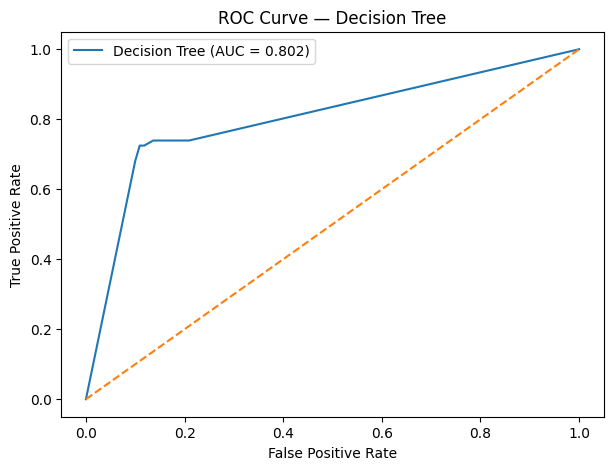

In [68]:
fpr_tree, tpr_tree, thresholds_tree = roc_curve(
    y_test,
    y_prob_tree
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {auc_tree:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree")
plt.legend()

plt.show()

In [69]:
tree_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_tree,
    "Precision": precision_tree,
    "Recall": recall_tree,
    "F1": f1_tree,
    "AUC": auc_tree
}

tree_results

{'Model': 'Decision Tree',
 'Accuracy': 0.8212290502793296,
 'Precision': 0.7936507936507936,
 'Recall': 0.7246376811594203,
 'F1': 0.7575757575757576,
 'AUC': np.float64(0.8018445322793148)}

# Random Forest

In [70]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [71]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

In [72]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [73]:
y_pred_rf = random_forest_pipeline.predict(X_test)

In [74]:
print("Actual values:")
print(y_test.head(10).values)

print("\nPredicted values:")
print(y_pred_rf[:10])

Actual values:
[0 0 1 0 1 1 1 0 0 0]

Predicted values:
[0 0 0 0 1 0 1 1 1 0]


# Accuracy

In [75]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")

Random Forest Accuracy: 0.8156
Random Forest Accuracy: 81.56%


# Precision, Recall, F1

In [76]:
precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")

Precision: 0.7903
Recall:    0.7101
F1 Score:  0.7481


In [77]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



# Confusion Matrix

In [78]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

[[97 13]
 [20 49]]


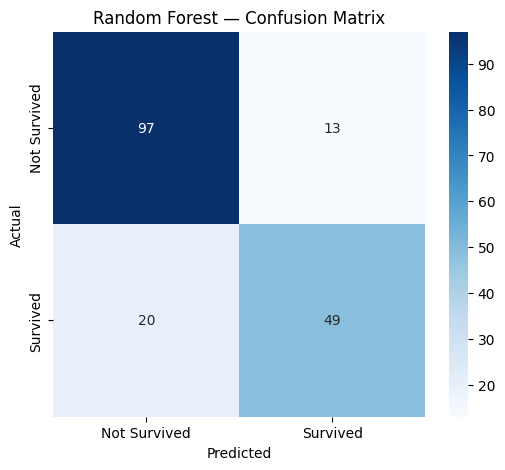

In [79]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC and AUC Curve

In [80]:
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [81]:
auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print(f"Random Forest AUC: {auc_rf:.4f}")

Random Forest AUC: 0.8365


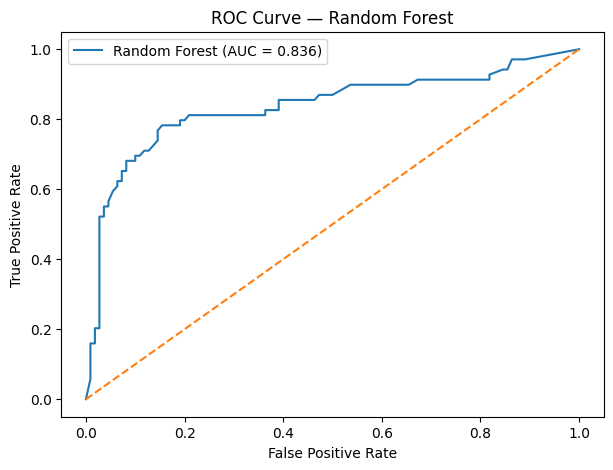

In [82]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()

plt.show()

In [83]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1": f1_rf,
    "AUC": auc_rf
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.8156424581005587,
 'Precision': 0.7903225806451613,
 'Recall': 0.7101449275362319,
 'F1': 0.7480916030534351,
 'AUC': np.float64(0.8364953886693017)}

# Model Comparision

In [84]:
model_comparison = pd.DataFrame([
    logistic_results,
    tree_results,
    rf_results
])

model_comparison

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.804469,0.783333,0.681159,0.728682,0.850988
1,Decision Tree,0.821229,0.793651,0.724638,0.757576,0.801845
2,Random Forest,0.815642,0.790323,0.710145,0.748092,0.836495


In [85]:
model_comparison.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,AUC
1,Decision Tree,0.821229,0.793651,0.724638,0.757576,0.801845
2,Random Forest,0.815642,0.790323,0.710145,0.748092,0.836495
0,Logistic Regression,0.804469,0.783333,0.681159,0.728682,0.850988


In [86]:
model_comparison.sort_values(
    by="AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.804469,0.783333,0.681159,0.728682,0.850988
2,Random Forest,0.815642,0.790323,0.710145,0.748092,0.836495
1,Decision Tree,0.821229,0.793651,0.724638,0.757576,0.801845


# Model Comparision

In [87]:
model_comparison

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.804469,0.783333,0.681159,0.728682,0.850988
1,Decision Tree,0.821229,0.793651,0.724638,0.757576,0.801845
2,Random Forest,0.815642,0.790323,0.710145,0.748092,0.836495


In [88]:
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8045,0.7833,0.6812,0.7287,0.8510
1,Decision Tree,0.8212,0.7937,0.7246,0.7576,0.8018
2,Random Forest,0.8156,0.7903,0.7101,0.7481,0.8365


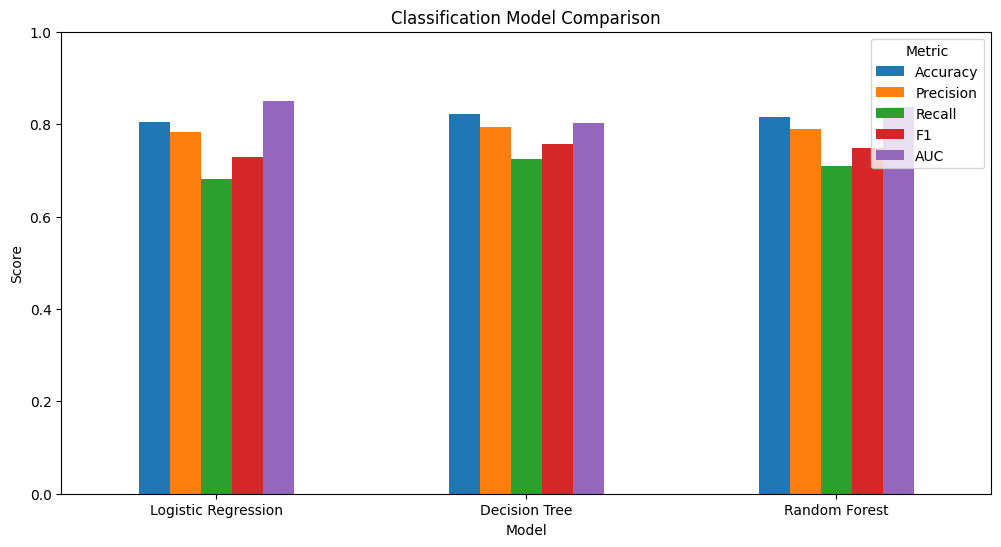

In [89]:
comparison_plot = model_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "AUC"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric")

plt.show()

In [90]:
cm_logistic
cm_tree
cm_rf

array([[97, 13],
       [20, 49]])

In [91]:
print("Logistic Regression")
print(cm_logistic)

Logistic Regression
[[97 13]
 [22 47]]


In [92]:
print("Decision Tree")
print(cm_tree)

Decision Tree
[[97 13]
 [19 50]]


In [93]:
print("Random Forest")
print(cm_rf)

Random Forest
[[97 13]
 [20 49]]


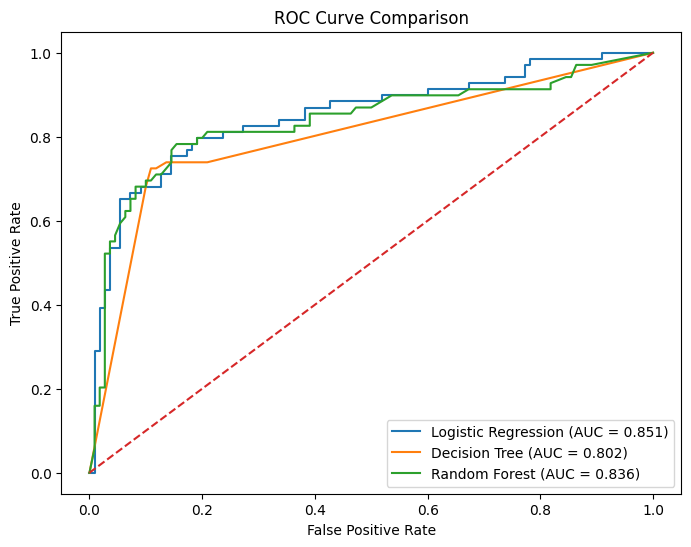

In [94]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {auc_tree:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

# Save Model

In [95]:
model_comparison.to_csv(
    "model_comparison_baseline.csv",
    index=False
)

In [96]:
model_comparison

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.804469,0.783333,0.681159,0.728682,0.850988
1,Decision Tree,0.821229,0.793651,0.724638,0.757576,0.801845
2,Random Forest,0.815642,0.790323,0.710145,0.748092,0.836495


# Class Distribution

In [97]:
print("Training set class distribution:")
print(y_train.value_counts())

print("\nTraining set class percentage:")
print(y_train.value_counts(normalize=True) * 100)

Training set class distribution:
survived
0    439
1    273
Name: count, dtype: int64

Training set class percentage:
survived
0    61.657303
1    38.342697
Name: proportion, dtype: float64


# Install SMOTE

In [98]:
!pip install -q imbalanced-learn

# Import SMOTE

In [99]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Baseline Random Forest

In [100]:
baseline_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

baseline_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", baseline_rf)
    ]
)

baseline_rf_pipeline.fit(X_train, y_train)

y_pred_baseline = baseline_rf_pipeline.predict(X_test)
y_prob_baseline = baseline_rf_pipeline.predict_proba(X_test)[:, 1]

In [101]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
baseline_auc = roc_auc_score(y_test, y_prob_baseline)

print("Baseline Random Forest")
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1 Score :", round(baseline_f1, 4))
print("AUC      :", round(baseline_auc, 4))

Baseline Random Forest
Accuracy : 0.8156
Precision: 0.7903
Recall   : 0.7101
F1 Score : 0.7481
AUC      : 0.8365


# Class Weight

In [102]:
balanced_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

balanced_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", balanced_rf)
    ]
)

balanced_rf_pipeline.fit(X_train, y_train)

y_pred_balanced = balanced_rf_pipeline.predict(X_test)
y_prob_balanced = balanced_rf_pipeline.predict_proba(X_test)[:, 1]

In [103]:
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)
balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)
balanced_auc = roc_auc_score(y_test, y_prob_balanced)

print("Balanced Random Forest")
print("Accuracy :", round(balanced_accuracy, 4))
print("Precision:", round(balanced_precision, 4))
print("Recall   :", round(balanced_recall, 4))
print("F1 Score :", round(balanced_f1, 4))
print("AUC      :", round(balanced_auc, 4))

Balanced Random Forest
Accuracy : 0.8101
Precision: 0.7869
Recall   : 0.6957
F1 Score : 0.7385
AUC      : 0.8277


# SMOTE

In [104]:
smote = SMOTE(random_state=42)

smote_rf_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [105]:
smote_rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', RandomForestClassifier(random_state=42))])

In [106]:
y_pred_smote = smote_rf_pipeline.predict(X_test)
y_prob_smote = smote_rf_pipeline.predict_proba(X_test)[:, 1]

In [107]:
smote_accuracy = accuracy_score(y_test, y_pred_smote)
smote_precision = precision_score(y_test, y_pred_smote)
smote_recall = recall_score(y_test, y_pred_smote)
smote_f1 = f1_score(y_test, y_pred_smote)
smote_auc = roc_auc_score(y_test, y_prob_smote)

print("SMOTE Random Forest")
print("Accuracy :", round(smote_accuracy, 4))
print("Precision:", round(smote_precision, 4))
print("Recall   :", round(smote_recall, 4))
print("F1 Score :", round(smote_f1, 4))
print("AUC      :", round(smote_auc, 4))

SMOTE Random Forest
Accuracy : 0.8045
Precision: 0.75
Recall   : 0.7391
F1 Score : 0.7445
AUC      : 0.8298


# Compare 3 Models

In [108]:
imbalance_comparison = pd.DataFrame([
    {
        "Model": "Baseline Random Forest",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "F1": baseline_f1,
        "AUC": baseline_auc
    },
    {
        "Model": "Balanced Random Forest",
        "Accuracy": balanced_accuracy,
        "Precision": balanced_precision,
        "Recall": balanced_recall,
        "F1": balanced_f1,
        "AUC": balanced_auc
    },
    {
        "Model": "SMOTE Random Forest",
        "Accuracy": smote_accuracy,
        "Precision": smote_precision,
        "Recall": smote_recall,
        "F1": smote_f1,
        "AUC": smote_auc
    }
])

imbalance_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Baseline Random Forest,0.8156,0.7903,0.7101,0.7481,0.8365
1,Balanced Random Forest,0.8101,0.7869,0.6957,0.7385,0.8277
2,SMOTE Random Forest,0.8045,0.7500,0.7391,0.7445,0.8298


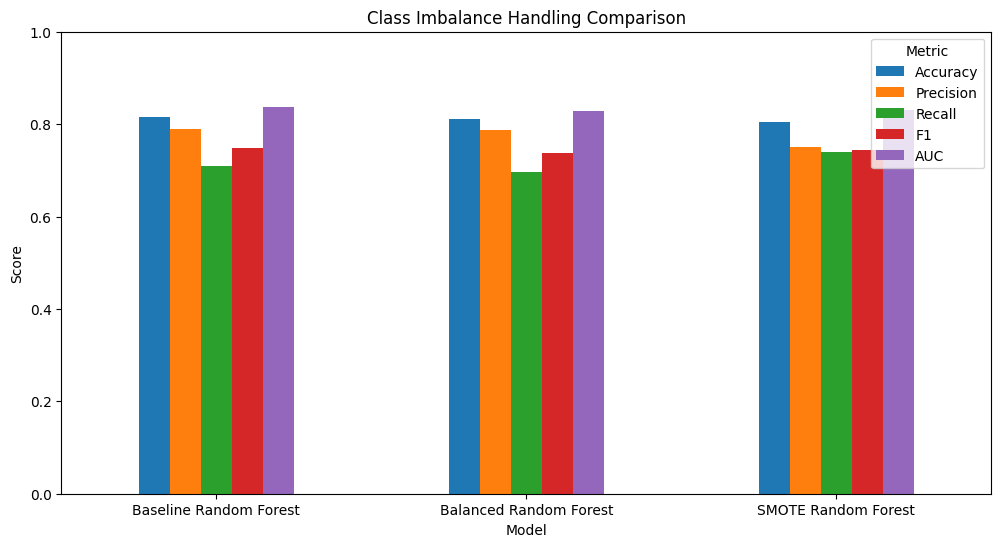

In [109]:
imbalance_plot = imbalance_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "AUC"]
]

imbalance_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Class Imbalance Handling Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()

In [110]:
imbalance_comparison.to_csv(
    "class_imbalance_comparison.csv",
    index=False
)

# Hyperparameter Tuning

In [111]:
from sklearn.model_selection import GridSearchCV

In [112]:
tuned_rf = RandomForestClassifier(
    random_state=42,
    oob_score=True,
    bootstrap=True
)

In [113]:
tuned_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", tuned_rf)
    ]
)

In [114]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

In [115]:
grid_search = GridSearchCV(
    estimator=tuned_rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [116]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['sex',
                                                                          'embarked',
                                                                          'alone'])])),
                                       ('model',
                                        RandomForestClassifier(oob_score=True,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [117]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 200}


In [118]:
print("Best Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))

Best Cross-Validation F1 Score:
0.7417


In [119]:
best_rf_model = grid_search.best_estimator_.named_steps["model"]

In [120]:
oob_score = best_rf_model.oob_score_

print("OOB Score:")
print(round(oob_score, 4))

OOB Score:
0.8244


In [121]:
best_rf_pipeline = grid_search.best_estimator_

y_pred_tuned = best_rf_pipeline.predict(X_test)
y_prob_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]

In [122]:
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

In [123]:
print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1 Score :", round(tuned_f1, 4))
print("AUC      :", round(tuned_auc, 4))
print("OOB Score:", round(oob_score, 4))

Tuned Random Forest Results
---------------------------
Accuracy : 0.7989
Precision: 0.7797
Recall   : 0.6667
F1 Score : 0.7188
AUC      : 0.8343
OOB Score: 0.8244


In [124]:
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



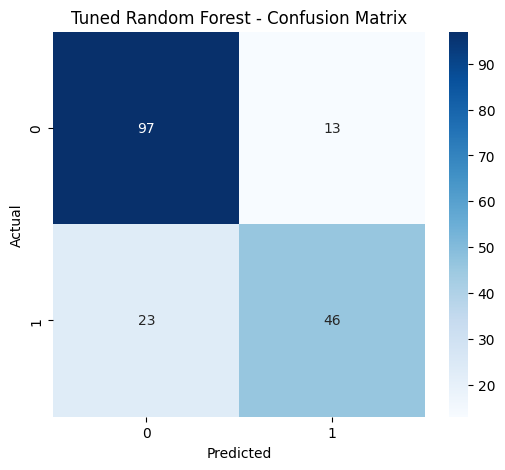

In [125]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [126]:
tuning_results = pd.DataFrame([{
    "Best_n_estimators": grid_search.best_params_["model__n_estimators"],
    "Best_max_depth": grid_search.best_params_["model__max_depth"],
    "Best_max_features": grid_search.best_params_["model__max_features"],
    "CV_F1": grid_search.best_score_,
    "Test_Accuracy": tuned_accuracy,
    "Test_Precision": tuned_precision,
    "Test_Recall": tuned_recall,
    "Test_F1": tuned_f1,
    "Test_AUC": tuned_auc,
    "OOB_Score": oob_score
}])

tuning_results.round(4)

,Best_n_estimators,Best_max_depth,Best_max_features,CV_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC,OOB_Score
0,200,10,sqrt,0.7417,0.7989,0.7797,0.6667,0.7188,0.8343,0.8244


In [127]:
tuning_results.to_csv(
    "random_forest_tuning_results.csv",
    index=False
)

# Regression

In [128]:
y_reg = df["fare"]

X_reg = df.drop(
    columns=[
        "fare",
        "survived",
        "alive",
        "class",
        "embark_town",
        "who",
        "adult_male"
    ]
)

In [130]:
print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)

print("\nRegression features:")
print(X_reg.columns.tolist())

print("\nMissing values:")
print(X_reg.isnull().sum())

X_reg shape: (891, 7)
y_reg shape: (891,)

Regression features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked', 'alone']

Missing values:
pclass      0
sex         0
age         0
sibsp       0
parch       0
embarked    0
alone       0
dtype: int64


In [132]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.20, random_state=42)

In [133]:
reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked",
    "alone"
]

In [134]:
reg_numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [135]:
reg_categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [138]:
reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            reg_numeric_transformer,
            reg_numeric_features
        ),
        (
            "cat",
            reg_categorical_transformer,
            reg_categorical_features
        )
    ]
)

# Linear Regression

In [136]:
from sklearn.linear_model import LinearRegression

In [139]:
linear_regression = LinearRegression()

regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("model", linear_regression)
    ]
)

In [140]:
regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('model', LinearRegression())])

In [141]:
y_reg_pred = regression_pipeline.predict(X_reg_test)

In [142]:
regression_predictions = pd.DataFrame({
    "Actual_Fare": y_reg_test.values,
    "Predicted_Fare": y_reg_pred
})

regression_predictions.head(10)

,Actual_Fare,Predicted_Fare
0,15.2458,34.149184
1,10.5000,31.080454
2,7.9250,-2.106271
3,33.0000,46.483973
4,11.2417,27.855811
5,78.8500,69.415084
6,7.7500,8.293682
7,18.0000,8.668113
8,7.7500,9.302063
9,26.2833,90.775848


In [143]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [144]:
mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

print("MAE:", round(mae, 4))

MAE: 20.8084


In [145]:
rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

print("RMSE:", round(rmse, 4))

RMSE: 30.511


In [146]:
r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

print("R²:", round(r2, 4))

R²: 0.3984


In [147]:
X_reg_test_transformed = (
    regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_test)
)

In [148]:
n = X_reg_test_transformed.shape[0]
p = X_reg_test_transformed.shape[1]

print("Number of observations (n):", n)
print("Number of predictors (p):", p)

Number of observations (n): 179
Number of predictors (p): 11


In [149]:
adjusted_r2 = 1 - (
    (1 - r2) * (n - 1)
    / (n - p - 1)
)

print("Adjusted R²:", round(adjusted_r2, 4))

Adjusted R²: 0.3588


# Calculating Errors

In [150]:
regression_results = pd.DataFrame([{
    "Model": "Multivariate Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Adjusted_R2": adjusted_r2
}])

regression_results.round(4)

,Model,MAE,RMSE,R2,Adjusted_R2
0,Multivariate Linear Regression,20.8084,30.511,0.3984,0.3588


In [151]:
residuals = y_reg_test - y_reg_pred

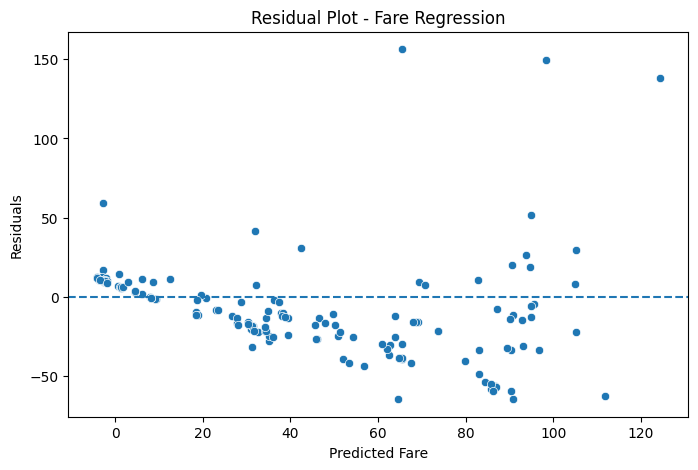

In [152]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Residual Plot - Fare Regression")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")

plt.show()

In [153]:
regression_results.to_csv(
    "fare_regression_results.csv",
    index=False
)

In [154]:
regression_predictions.to_csv(
    "fare_regression_predictions.csv",
    index=False
)

# Complete Pipeline

In [155]:
print("Original Model Comparison")
display(model_comparison.round(4))

Original Model Comparison


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8045,0.7833,0.6812,0.7287,0.8510
1,Decision Tree,0.8212,0.7937,0.7246,0.7576,0.8018
2,Random Forest,0.8156,0.7903,0.7101,0.7481,0.8365


In [156]:
print("Class Imbalance Comparison")
display(imbalance_comparison.round(4))

Class Imbalance Comparison


,Model,Accuracy,Precision,Recall,F1,AUC
0,Baseline Random Forest,0.8156,0.7903,0.7101,0.7481,0.8365
1,Balanced Random Forest,0.8101,0.7869,0.6957,0.7385,0.8277
2,SMOTE Random Forest,0.8045,0.7500,0.7391,0.7445,0.8298


In [157]:
print("Tuned Random Forest Results")
display(tuning_results.round(4))

Tuned Random Forest Results


,Best_n_estimators,Best_max_depth,Best_max_features,CV_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC,OOB_Score
0,200,10,sqrt,0.7417,0.7989,0.7797,0.6667,0.7188,0.8343,0.8244


In [159]:
final_pipeline = grid_search.best_estimator_
print(final_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                  

In [160]:
final_pred = final_pipeline.predict(X_test)
final_prob = final_pipeline.predict_proba(X_test)[:, 1]

In [161]:
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)
final_auc = roc_auc_score(y_test, final_prob)

In [162]:
print("FINAL CLASSIFICATION MODEL")
print("--------------------------")
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1 Score :", round(final_f1, 4))
print("AUC      :", round(final_auc, 4))

FINAL CLASSIFICATION MODEL
--------------------------
Accuracy : 0.7989
Precision: 0.7797
Recall   : 0.6667
F1 Score : 0.7188
AUC      : 0.8343


In [163]:
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



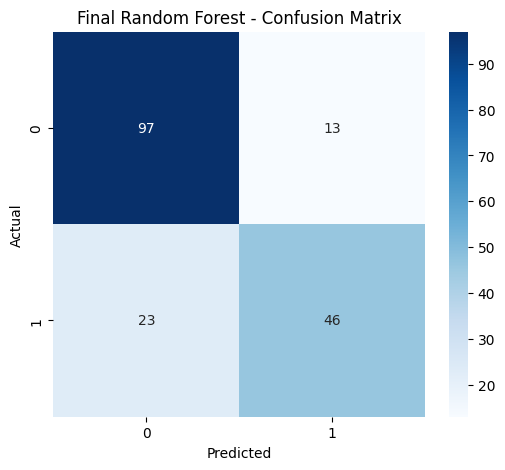

In [164]:
final_cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Final Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Model Saving JOBLIB

In [165]:
import joblib

joblib.dump(
    final_pipeline,
    "final_titanic_pipeline.joblib"
)

['final_titanic_pipeline.joblib']

In [166]:
import os

print(
    "File exists:",
    os.path.exists("final_titanic_pipeline.joblib")
)

File exists: True


In [167]:
del final_pipeline

loaded_pipeline = joblib.load(
    "final_titanic_pipeline.joblib"
)

print(loaded_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked',
                                                   'alone'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                  

In [168]:
sample_passenger = pd.DataFrame([{
    "pclass": 3,
    "sex": "male",
    "age": 30,
    "sibsp": 0,
    "parch": 0,
    "fare": 20.0,
    "embarked": "S",
    "alone": True
}])

sample_passenger

,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,3,male,30,0,0,20.0,S,True


In [169]:
prediction = loaded_pipeline.predict(
    sample_passenger
)

print("Prediction:", prediction[0])

Prediction: 0


In [170]:
probability = loaded_pipeline.predict_proba(
    sample_passenger
)

print("Probability of class 0:", round(probability[0][0], 4))
print("Probability of class 1:", round(probability[0][1], 4))

Probability of class 0: 0.7053
Probability of class 1: 0.2947


In [171]:
def predict_survival(passenger_data):
    passenger_df = pd.DataFrame([passenger_data])

    prediction = loaded_pipeline.predict(passenger_df)[0]
    probability = loaded_pipeline.predict_proba(passenger_df)[0][1]

    result = "Survived" if prediction == 1 else "Did Not Survive"

    return {
        "Prediction": result,
        "Survival_Probability": round(probability, 4)
    }

In [172]:
new_passenger = {
    "pclass": 1,
    "sex": "female",
    "age": 25,
    "sibsp": 0,
    "parch": 0,
    "fare": 80.0,
    "embarked": "S",
    "alone": True
}

predict_survival(new_passenger)

{'Prediction': 'Survived', 'Survival_Probability': np.float64(0.965)}

In [173]:
final_model_summary = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1": final_f1,
    "AUC": final_auc,
    "CV_F1": grid_search.best_score_,
    "OOB_Score": best_rf_model.oob_score_
}])

final_model_summary.round(4)

,Model,Accuracy,Precision,Recall,F1,AUC,CV_F1,OOB_Score
0,Tuned Random Forest,0.7989,0.7797,0.6667,0.7188,0.8343,0.7417,0.8244


In [174]:
final_model_summary.to_csv(
    "final_model_summary.csv",
    index=False
)